In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import  datasets
from skimage import transform

In [13]:
def load_and_preprocess_image():
    """加载并预处理图像"""
    # 加载内置图像（这里使用 scipy 的 ascent，如果没有则使用 skimage 的 camera）
    try:
        img = datasets.ascent()
        print("使用 scipy.datasets.ascent 图像")
    except:
        from skimage import data
        img = data.camera()
        print("使用 skimage.data.camera 图像")

    print("img图像原始形状：", img.shape)
    # resize 到 128x128
    img_resized = transform.resize(img, (128, 128))

    # 确保是 float32 并归一化到 [0, 1]
    img_float = img_resized.astype(np.float32)
    if img_float.max() > 1.0:
        img_float = img_float / 255.0

    return img_float

In [14]:
def my_conv2d(img, kernel, stride=1, padding=0):
    """
    2D 卷积前向传播

    参数:
        img: (H, W) 输入图像
        kernel: (K, K) 卷积核
        stride: 步长
        padding: 填充大小

    返回:
        out: (H_out, W_out) 输出特征图
    """
    H, W = img.shape
    K = kernel.shape[0]
    P = padding
    S = stride

    padded_img = np.pad(img, ((P, P), (P, P)), mode='constant', constant_values=0)

    output_rows = []

    # 遍历行方向
    h_start = 0
    while h_start + K <= padded_img.shape[0]:
        output_cols = []
        # 遍历列方向
        w_start = 0
        while w_start + K <= padded_img.shape[1]:
            region = padded_img[h_start:h_start+K, w_start:w_start+K]
            output_cols.append(np.sum(region * kernel))
            w_start += S
        output_rows.append(output_cols)
        h_start += S

    # 将列表转换为 numpy 数组
    output = np.array(output_rows)

    return output

In [15]:
def my_maxpool2d(img, kernel_size=2, stride=2):
    """
    最大池化

    参数:
        img: (H, W) 输入特征图
        kernel_size: 池化窗口大小
        stride: 步长

    返回:
        out: (H_out, W_out) 池化后的特征图
    """
    H, W = img.shape
    K = kernel_size
    S = stride

    # 通过循环计算实际输出（不依赖公式结果）
    output_rows = []

    h_start = 0
    while h_start + K <= H:
        output_cols = []
        w_start = 0
        while w_start + K <= W:
            region = img[h_start:h_start+K, w_start:w_start+K]
            output_cols.append(np.max(region))
            w_start += S
        output_rows.append(output_cols)
        h_start += S

    output = np.array(output_rows)

    return output

In [16]:
def sobel_edge_detection(img):
    """应用 Sobel 核进行边缘检测"""
    # 定义 Sobel 核
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32)

    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=np.float32)

    # 应用卷积（padding=1 保证输出尺寸与输入相同）
    gx = my_conv2d(img, sobel_x, stride=1, padding=1)
    gy = my_conv2d(img, sobel_y, stride=1, padding=1)
    gx = abs(gx)
    gy = abs(gy)

    # 计算梯度幅值
    magnitude = np.sqrt(gx**2 + gy**2)

    # 归一化到 [0, 1] 便于显示
    gx_norm = (gx - gx.min()) / (gx.max() - gx.min() + 1e-8)
    gy_norm = (gy - gy.min()) / (gy.max() - gy.min() + 1e-8)
    mag_norm = (magnitude - magnitude.min()) / (magnitude.max() - magnitude.min() + 1e-8)

    return gx_norm, gy_norm, mag_norm

In [17]:
print("步骤1: 加载图像...")
img = load_and_preprocess_image()
H, W = img.shape
print(f"图像尺寸: {H}x{W}, 数据类型: {img.dtype}, 值域: [{img.min():.3f}, {img.max():.3f}]")

步骤1: 加载图像...
使用 scipy.datasets.ascent 图像
img图像原始形状： (512, 512)
图像尺寸: 128x128, 数据类型: float32, 值域: [0.017, 0.930]


In [18]:
print("步骤2: 测试卷积输出尺寸...")
test_kernel = np.ones((3, 3)) / 9  # 3x3 均值滤波核

# 测试不同参数组合
test_cases = [
    (1, 0),   # stride=1, padding=0
    (1, 1),   # stride=1, padding=1
    (2, 0),   # stride=2, padding=0
    (2, 1)    # stride=2, padding=1
]

for stride, padding in test_cases:
    H_out = (H + 2*padding - test_kernel.shape[0]) // stride + 1
    W_out = (W + 2*padding - test_kernel.shape[1]) // stride + 1
    print(f"  stride={stride}, padding={padding} -> 理论输出尺寸: {H_out}x{W_out}")

    # 实际调用验证
    out = my_conv2d(img, test_kernel, stride=stride, padding=padding)
    print(f"    实际输出: {out.shape}")
    assert out.shape == (H_out, W_out), "输出尺寸计算错误"

步骤2: 测试卷积输出尺寸...
  stride=1, padding=0 -> 理论输出尺寸: 126x126
    实际输出: (126, 126)
  stride=1, padding=1 -> 理论输出尺寸: 128x128
    实际输出: (128, 128)
  stride=2, padding=0 -> 理论输出尺寸: 63x63
    实际输出: (63, 63)
  stride=2, padding=1 -> 理论输出尺寸: 64x64
    实际输出: (64, 64)


In [19]:
print("步骤3: Sobel 边缘检测...")
gx, gy, magnitude = sobel_edge_detection(img)
print(f"  垂直边缘图尺寸: {gx.shape}")
print(f"  水平边缘图尺寸: {gy.shape}")

步骤3: Sobel 边缘检测...
  垂直边缘图尺寸: (128, 128)
  水平边缘图尺寸: (128, 128)


In [20]:
print("步骤4: Max Pooling 测试...")
pool_out = my_maxpool2d(img, kernel_size=2, stride=2)
print(f"  池化前尺寸: {magnitude.shape}")
print(f"  池化后尺寸: {pool_out.shape}")

步骤4: Max Pooling 测试...
  池化前尺寸: (128, 128)
  池化后尺寸: (64, 64)


步骤5: 生成可视化结果...


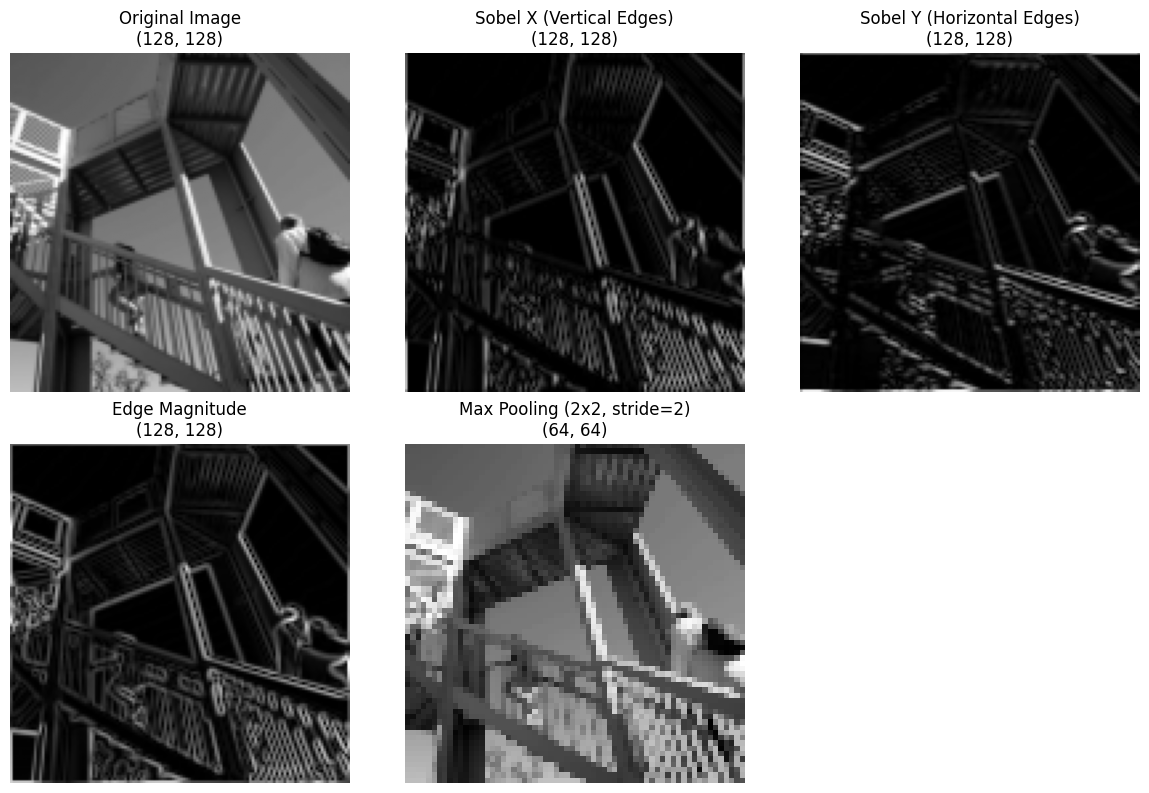

In [21]:
print("步骤5: 生成可视化结果...")
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# 第一行：原始图像和 Sobel 结果
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title(f'Original Image\n{img.shape}')
axes[0, 0].axis('off')

axes[0, 1].imshow(gx, cmap='gray')
axes[0, 1].set_title(f'Sobel X (Vertical Edges)\n{gx.shape}')
axes[0, 1].axis('off')

axes[0, 2].imshow(gy, cmap='gray')
axes[0, 2].set_title(f'Sobel Y (Horizontal Edges)\n{gy.shape}')
axes[0, 2].axis('off')

# 第二行：梯度幅值和池化结果
axes[1, 0].imshow(magnitude, cmap='gray')
axes[1, 0].set_title(f'Edge Magnitude\n{magnitude.shape}')
axes[1, 0].axis('off')

axes[1, 1].imshow(pool_out, cmap='gray')
axes[1, 1].set_title(f'Max Pooling (2x2, stride=2)\n{pool_out.shape}')
axes[1, 1].axis('off')
axes[1, 2].remove()

plt.tight_layout()
plt.show()